# Map_magnetic

Analysis of **existing** mapping data in `COSY/src/dat/<stem>/` (no COSY re-run from this notebook).

Same methodology as [`Map_lat.ipynb`](Map_lat.ipynb). To regenerate data use `run_mapping.py`.

**Measured quantity:** $\Delta\nu_s = \nu_{s,\mathrm{probe}} - \nu_{s,\mathrm{ref}}$.

**Scan target:** $|\xi_x|, |\xi_y| \le 20$ in integrals; theory plots use $\xi \in [-10,10]$, $\eta_1 \in [-1,1]$.

**3 sextupole families only:** SF1 (central, `SEXTGx1`), SF2 (near focusing quads, `SEXTGx2`), SD (near defocusing quads, `SEXTGy1`). All on bending arcs where dispersion is non-zero. Pattern per arc cell: `SF2 — SD — SF1 — SD — SF2`.

**Rollout:** `magnetic_2` … `magnetic_8` — three-family mapping scan (FR0: 5³, FR3: 3³); separate scan steps per mode.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Ensure imports work regardless of Jupyter kernel cwd
_cwd = Path.cwd()
if (_cwd / "map_lat_lib.py").is_file():
    ANALYSIS_DIR = _cwd
elif (_cwd / "COSY" / "analysis" / "map_lat_lib.py").is_file():
    ANALYSIS_DIR = _cwd / "COSY" / "analysis"
else:
    ANALYSIS_DIR = _cwd
sys.path.insert(0, str(ANALYSIS_DIR))

from map_lat_lib import (
    CHROM_ABS_LIMIT,
    DEFAULT_ROOT,
    audit_mapping_lattice,
    chrom_range_report,
    get_data,
    plot_verify_chrom_to_spin,
    print_mapping_audit,
    verify_chrom_model,
    verify_chrom_to_spin_link,
)
from plot_magnetic_map import plot_lattice

lattices = [f"magnetic_{n}" for n in range(2, 9)]
MODES = ["FR0", "FR3"]

In [2]:
from IPython.display import display

# What is actually scanned? (3 family gradients, not per-magnet fields)
for lat in lattices:
    print_mapping_audit(lat, DEFAULT_ROOT)
    display(pd.DataFrame([audit_mapping_lattice(lat, DEFAULT_ROOT)]))


=== Mapping audit: magnetic_2 ===
Physical sextupoles: 10 (SF1=2, SF2=4, SD=4)
Powered families: 3  |  Scan varies: SGx1, SGx2, SGy1
Wiring: SF1<-SEXTGx1=True, SF2<-SEXTGx2=True, SD<-SEXTGy1=True, SD1_present=False
Grid: FR0=125 pts, FR3=27 pts
  FR0: n=125, SGy2 varies=False, |xi| max ~18.1, in_range=True, suggested steps=(np.float64(0.004422), np.float64(-0.006634))
  FR3: n=27, SGy2 varies=False, |xi| max ~9.5, in_range=True, suggested steps=(np.float64(0.008391), np.float64(-0.012586))


,lattice,physical_SF1,physical_SF2,physical_SD,physical_sextupoles_total,independent_powered_families,scan_parameters,FR0_grid_points,FR3_grid_points,SF1_from_SEXTGx1,...,FR0_xi_in_range,FR0_xi_x_max,FR0_xi_y_max,FR0_suggested_steps,FR3_n_points,FR3_SGy2_varies,FR3_xi_in_range,FR3_xi_x_max,FR3_xi_y_max,FR3_suggested_steps
0,magnetic_2,2,4,4,10,3,"SGx1, SGx2, SGy1",125,27,True,...,True,16.932022,18.089743,"(0.004422, -0.006634)",27,False,True,6.65224,9.534482,"(0.008391, -0.012586)"



=== Mapping audit: magnetic_3 ===
Physical sextupoles: 15 (SF1=3, SF2=6, SD=6)
Powered families: 3  |  Scan varies: SGx1, SGx2, SGy1
Wiring: SF1<-SEXTGx1=True, SF2<-SEXTGx2=True, SD<-SEXTGy1=True, SD1_present=False
Grid: FR0=125 pts, FR3=27 pts
  FR0: n=125, SGy2 varies=False, |xi| max ~17.4, in_range=True, suggested steps=(np.float64(0.009193), np.float64(-0.01379))
  FR3: n=27, SGy2 varies=False, |xi| max ~8.8, in_range=True, suggested steps=(np.float64(0.018201), np.float64(-0.027302))


,lattice,physical_SF1,physical_SF2,physical_SD,physical_sextupoles_total,independent_powered_families,scan_parameters,FR0_grid_points,FR3_grid_points,SF1_from_SEXTGx1,...,FR0_xi_in_range,FR0_xi_x_max,FR0_xi_y_max,FR0_suggested_steps,FR3_n_points,FR3_SGy2_varies,FR3_xi_in_range,FR3_xi_x_max,FR3_xi_y_max,FR3_suggested_steps
0,magnetic_3,3,6,6,15,3,"SGx1, SGx2, SGy1",125,27,True,...,True,17.404232,15.491178,"(0.009193, -0.01379)",27,False,True,8.79062,4.408432,"(0.018201, -0.027302)"



=== Mapping audit: magnetic_4 ===
Physical sextupoles: 20 (SF1=4, SF2=8, SD=8)
Powered families: 3  |  Scan varies: SGx1, SGx2, SGy1
Wiring: SF1<-SEXTGx1=True, SF2<-SEXTGx2=True, SD<-SEXTGy1=True, SD1_present=False
Grid: FR0=125 pts, FR3=27 pts
  FR0: n=125, SGy2 varies=False, |xi| max ~18.4, in_range=True, suggested steps=(np.float64(0.015767), np.float64(-0.02365))
  FR3: n=27, SGy2 varies=False, |xi| max ~9.1, in_range=True, suggested steps=(np.float64(0.031843), np.float64(-0.047765))


,lattice,physical_SF1,physical_SF2,physical_SD,physical_sextupoles_total,independent_powered_families,scan_parameters,FR0_grid_points,FR3_grid_points,SF1_from_SEXTGx1,...,FR0_xi_in_range,FR0_xi_x_max,FR0_xi_y_max,FR0_suggested_steps,FR3_n_points,FR3_SGy2_varies,FR3_xi_in_range,FR3_xi_x_max,FR3_xi_y_max,FR3_suggested_steps
0,magnetic_4,4,8,8,20,3,"SGx1, SGx2, SGy1",125,27,True,...,True,18.392978,16.413452,"(0.015767, -0.02365)",27,False,True,9.107041,5.444556,"(0.031843, -0.047765)"



=== Mapping audit: magnetic_5 ===
Physical sextupoles: 25 (SF1=5, SF2=10, SD=10)
Powered families: 3  |  Scan varies: SGx1, SGx2, SGy1
Wiring: SF1<-SEXTGx1=True, SF2<-SEXTGx2=True, SD<-SEXTGy1=True, SD1_present=False
Grid: FR0=125 pts, FR3=27 pts
  FR0: n=125, SGy2 varies=False, |xi| max ~17.3, in_range=True, suggested steps=(np.float64(0.023102), np.float64(-0.034653))
  FR3: n=27, SGy2 varies=False, |xi| max ~8.2, in_range=True, suggested steps=(np.float64(0.054857), np.float64(-0.082286))


,lattice,physical_SF1,physical_SF2,physical_SD,physical_sextupoles_total,independent_powered_families,scan_parameters,FR0_grid_points,FR3_grid_points,SF1_from_SEXTGx1,...,FR0_xi_in_range,FR0_xi_x_max,FR0_xi_y_max,FR0_suggested_steps,FR3_n_points,FR3_SGy2_varies,FR3_xi_in_range,FR3_xi_x_max,FR3_xi_y_max,FR3_suggested_steps
0,magnetic_5,5,10,10,25,3,"SGx1, SGx2, SGy1",125,27,True,...,True,17.314584,12.007402,"(0.023102, -0.034653)",27,False,True,7.61214,8.205596,"(0.054857, -0.082286)"


In [3]:
rows = []
for lat in lattices:
    for mode in MODES:
        df = get_data(lat, mode, DEFAULT_ROOT)
        if df is None:
            rows.append({"lattice": lat, "mode": mode, "status": "missing"})
            continue
        rep = chrom_range_report(df, limit=CHROM_ABS_LIMIT)
        rows.append({"lattice": lat, "mode": mode, **rep})
        flag = "OK" if rep["xi_in_range"] else "WARN: |xi| > limit"
        print(
            f"{lat} {mode}: xi_x=[{rep['chrom_x_min']:.2f}, {rep['chrom_x_max']:.2f}] "
            f"xi_y=[{rep['chrom_y_min']:.2f}, {rep['chrom_y_max']:.2f}] "
            f"eta_1=[{rep['eta_1_min']:.2f}, {rep['eta_1_max']:.2f}]  ({flag})"
        )

pd.DataFrame(rows)

magnetic_2 FR0: xi_x=[-1.84, 16.93] xi_y=[-1.85, 18.09] eta_1=[-6.47, 2.34]  (OK)
magnetic_2 FR3: xi_x=[-1.71, 6.65] xi_y=[-1.54, 9.53] eta_1=[-2.77, 1.69]  (OK)
magnetic_3 FR0: xi_x=[-3.74, 17.40] xi_y=[-3.75, 15.49] eta_1=[-1.33, 1.41]  (OK)
magnetic_3 FR3: xi_x=[-3.46, 8.79] xi_y=[-3.68, 4.41] eta_1=[-0.18, 1.22]  (OK)
magnetic_4 FR0: xi_x=[-5.49, 18.39] xi_y=[-5.48, 16.41] eta_1=[-0.16, 1.15]  (OK)
magnetic_4 FR3: xi_x=[-5.22, 9.11] xi_y=[-5.44, 3.36] eta_1=[0.39, 1.07]  (OK)
magnetic_5 FR0: xi_x=[-7.25, 17.31] xi_y=[-7.34, 12.01] eta_1=[0.38, 1.03]  (OK)
magnetic_5 FR3: xi_x=[-7.37, 7.61] xi_y=[-8.21, 1.61] eta_1=[0.65, 0.98]  (OK)


,lattice,mode,chrom_x_min,chrom_x_max,chrom_y_min,chrom_y_max,eta_1_min,eta_1_max,n_points,xi_in_range
0,magnetic_2,FR0,-1.840801,16.932022,-1.847679,18.089743,-6.467910,2.342666,125,True
1,magnetic_2,FR3,-1.713754,6.652240,-1.538274,9.534482,-2.772636,1.690863,27,True
2,magnetic_3,FR0,-3.735648,17.404232,-3.745471,15.491178,-1.332764,1.406010,125,True
3,magnetic_3,FR3,-3.461790,8.790620,-3.679293,4.408432,-0.179118,1.220849,27,True
4,magnetic_4,FR0,-5.488794,18.392978,-5.484727,16.413452,-0.161669,1.152533,125,True
5,magnetic_4,FR3,-5.221736,9.107041,-5.444556,3.359503,0.389502,1.067058,27,True
6,magnetic_5,FR0,-7.251794,17.314584,-7.342234,12.007402,0.376167,1.025878,125,True
7,magnetic_5,FR3,-7.369790,7.612140,-8.205596,1.608678,0.647532,0.984691,27,True


In [4]:
for lat in lattices:
    for mode in MODES:
        df = get_data(lat, mode, DEFAULT_ROOT)
        if df is None:
            continue
        print(f"\n=== {lat} {mode}: chrom linear model ===")
        print(verify_chrom_model(df))
        print(f"=== {lat} {mode}: xi -> spin link (P0) ===")
        print(verify_chrom_to_spin_link(df, suffix=""))
        print(f"=== {lat} {mode}: xi -> spin link (P1) ===")
        print(verify_chrom_to_spin_link(df, suffix="_1"))


=== magnetic_2 FR0: chrom linear model ===
{'r2_chrom_x': 1.0, 'max_res_chrom_x': 6.123990203832363e-13, 'r2_chrom_y': 1.0, 'max_res_chrom_y': 5.95967719618784e-13, 'r2_eta_1': 1.0, 'max_res_eta_1': 7.194245199571014e-14}
=== magnetic_2 FR0: xi -> spin link (P0) ===
{'r2_x': 0.999999950426476, 'max_res_x': 4.093099192802302e-13, 'r2_y': 0.999996433657342, 'max_res_y': 1.1143128419975542e-11, 'r2_z': 0.9999999838654265, 'max_res_z': 9.267431266881948e-14}
=== magnetic_2 FR0: xi -> spin link (P1) ===
{'r2_x': 0.9999998016742639, 'max_res_x': 3.274533089071511e-12, 'r2_y': 0.9999857867934167, 'max_res_y': 8.914502935840505e-11, 'r2_z': 0.9999995974240009, 'max_res_z': 1.1584324388621512e-11}

=== magnetic_2 FR3: chrom linear model ===
{'r2_chrom_x': 1.0, 'max_res_chrom_x': 1.597224130733821e-08, 'r2_chrom_y': 0.9999999999999999, 'max_res_chrom_y': 4.76308392727276e-08, 'r2_eta_1': 0.9999999999999999, 'max_res_eta_1': 1.8927601375118286e-08}
=== magnetic_2 FR3: xi -> spin link (P0) ===
{'

In [5]:
for lat in lattices:
    for mode in MODES:
        df = get_data(lat, mode, DEFAULT_ROOT)
        if df is None:
            continue
        out_dir = DEFAULT_ROOT / lat / "plots"
        plot_verify_chrom_to_spin(lat, mode, df, suffix="", show=False, save_dir=out_dir)
        plot_verify_chrom_to_spin(lat, mode, df, suffix="_1", show=False, save_dir=out_dir)

OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2\plots\magnetic_2_verify_spin_link_FR0_P0.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2\plots\magnetic_2_verify_spin_link_FR0_P1.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2\plots\magnetic_2_verify_spin_link_FR3_P0.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2\plots\magnetic_2_verify_spin_link_FR3_P1.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_3\plots\magnetic_3_verify_spin_link_FR0_P0.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_3\plots\magnetic_3_verify_spin_link_FR0_P1.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_3\plots\magnetic_3_verify_spin_link_FR3_P0.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_3\plots\magnetic_3_verify_spin_link_FR3_P1.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_4\plots\magnetic_4_verify_spin_link_FR0_P0.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_4\plots\magnetic_4_verify_spin_link_FR0_P1.png
OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_4\plots\magnetic_4_verify_spin_link_FR3_P0.png
OK: C:\GIT

OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_2\plots\magnetic_2_dnu_s_vs_chrom.png


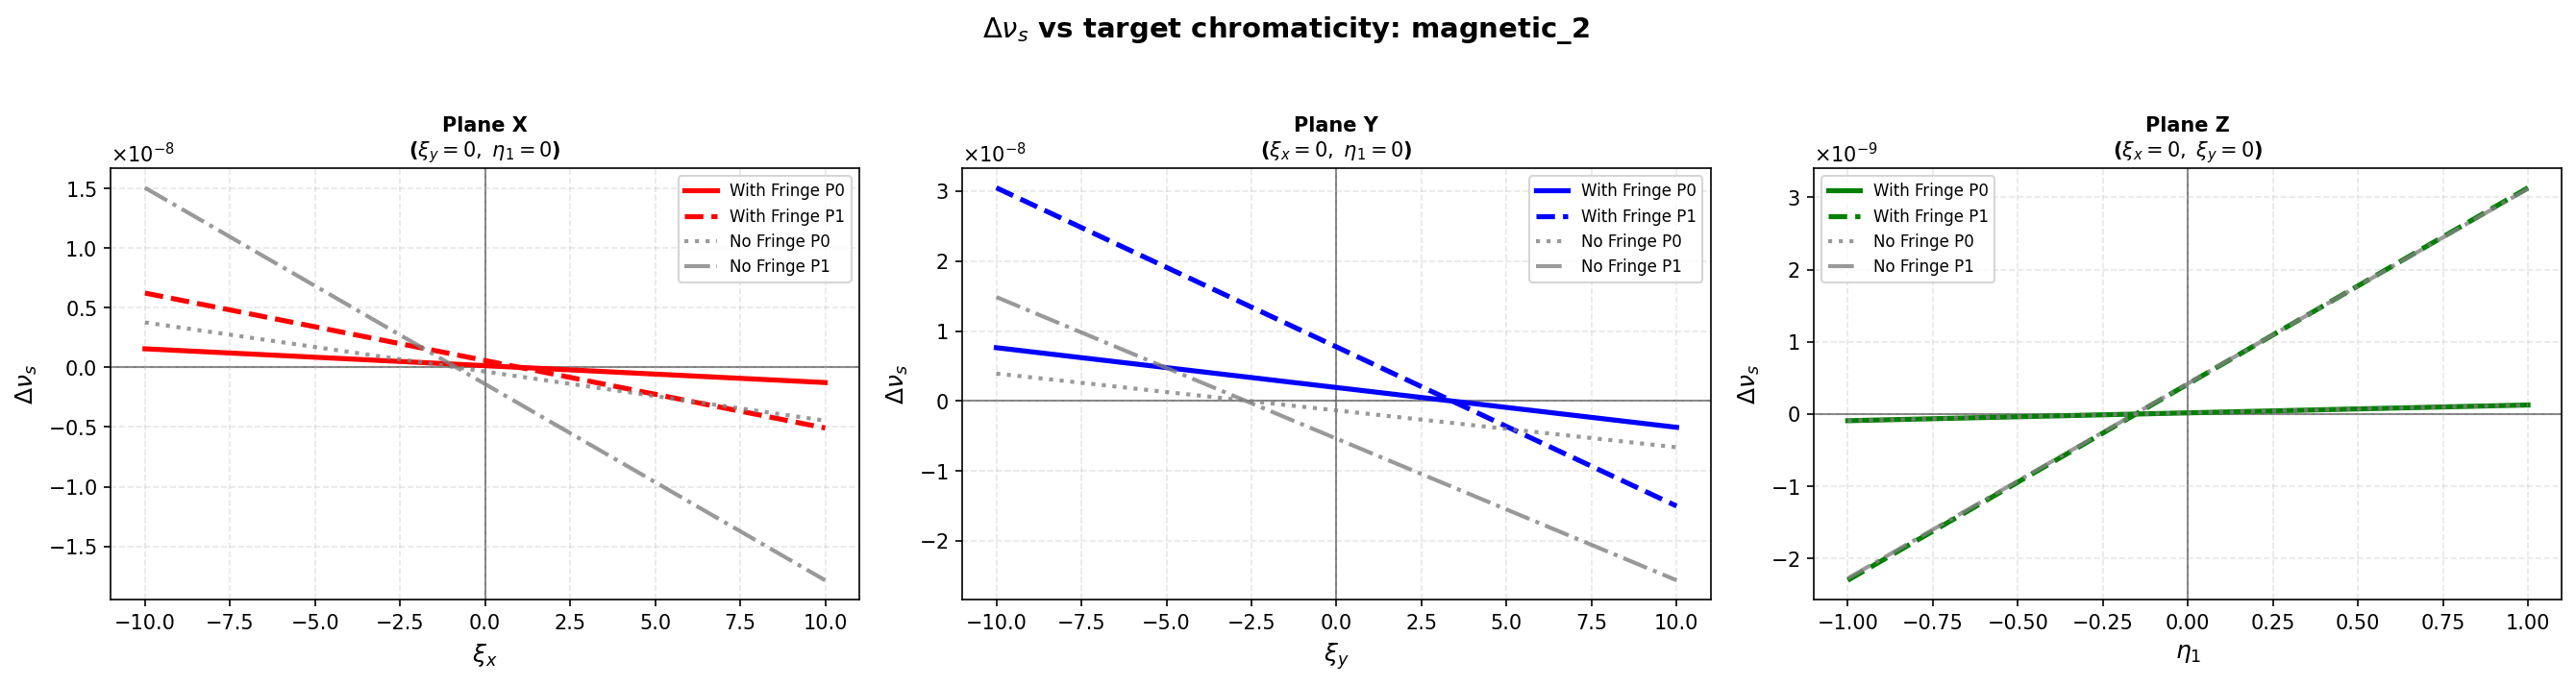

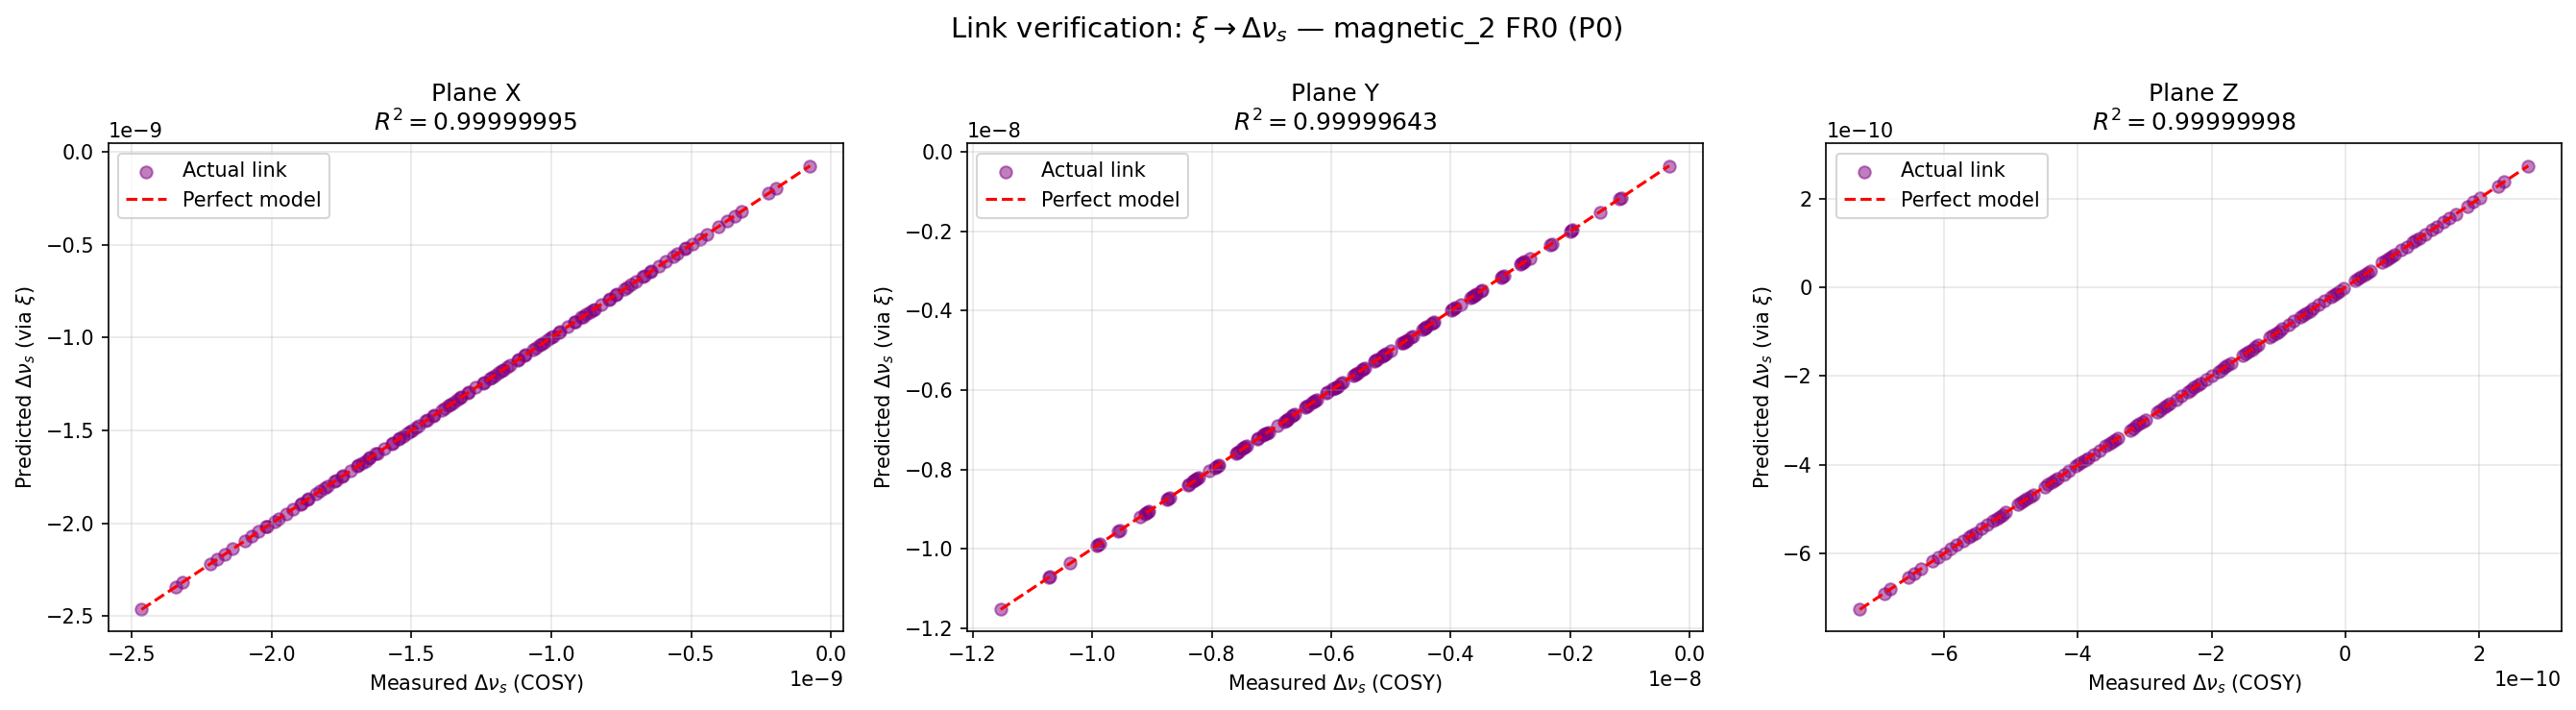

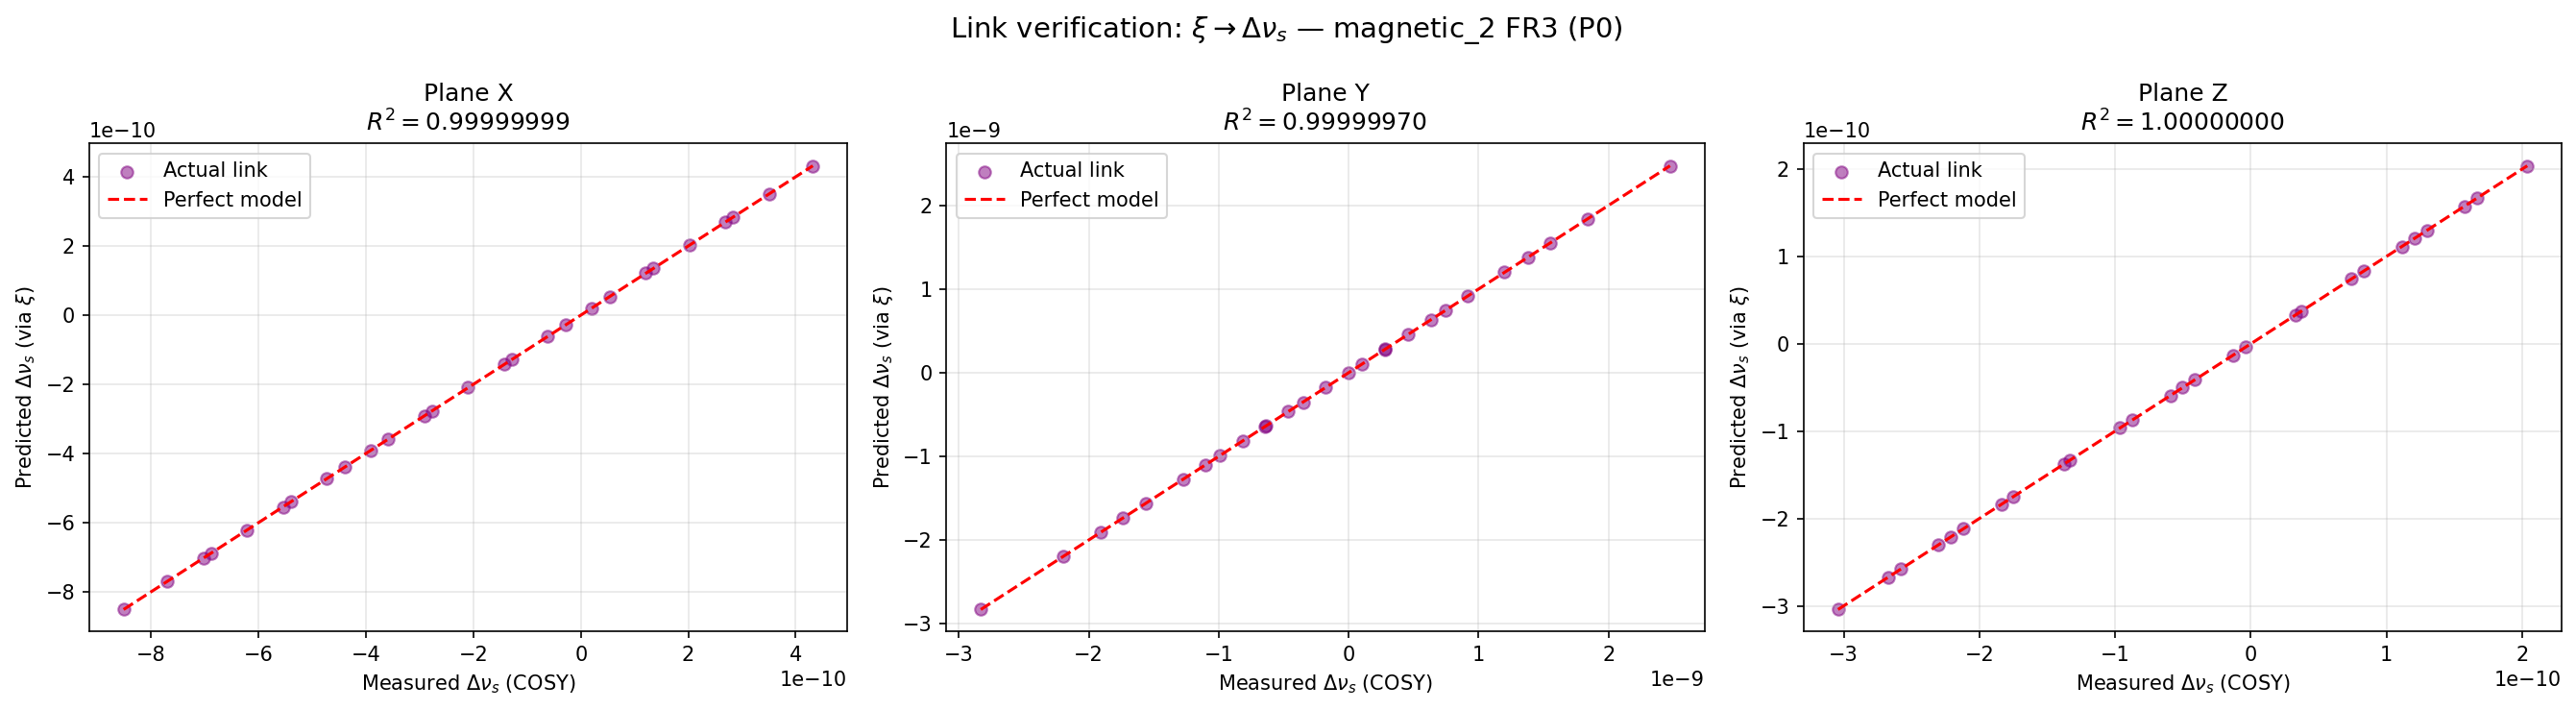

OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_3\plots\magnetic_3_dnu_s_vs_chrom.png


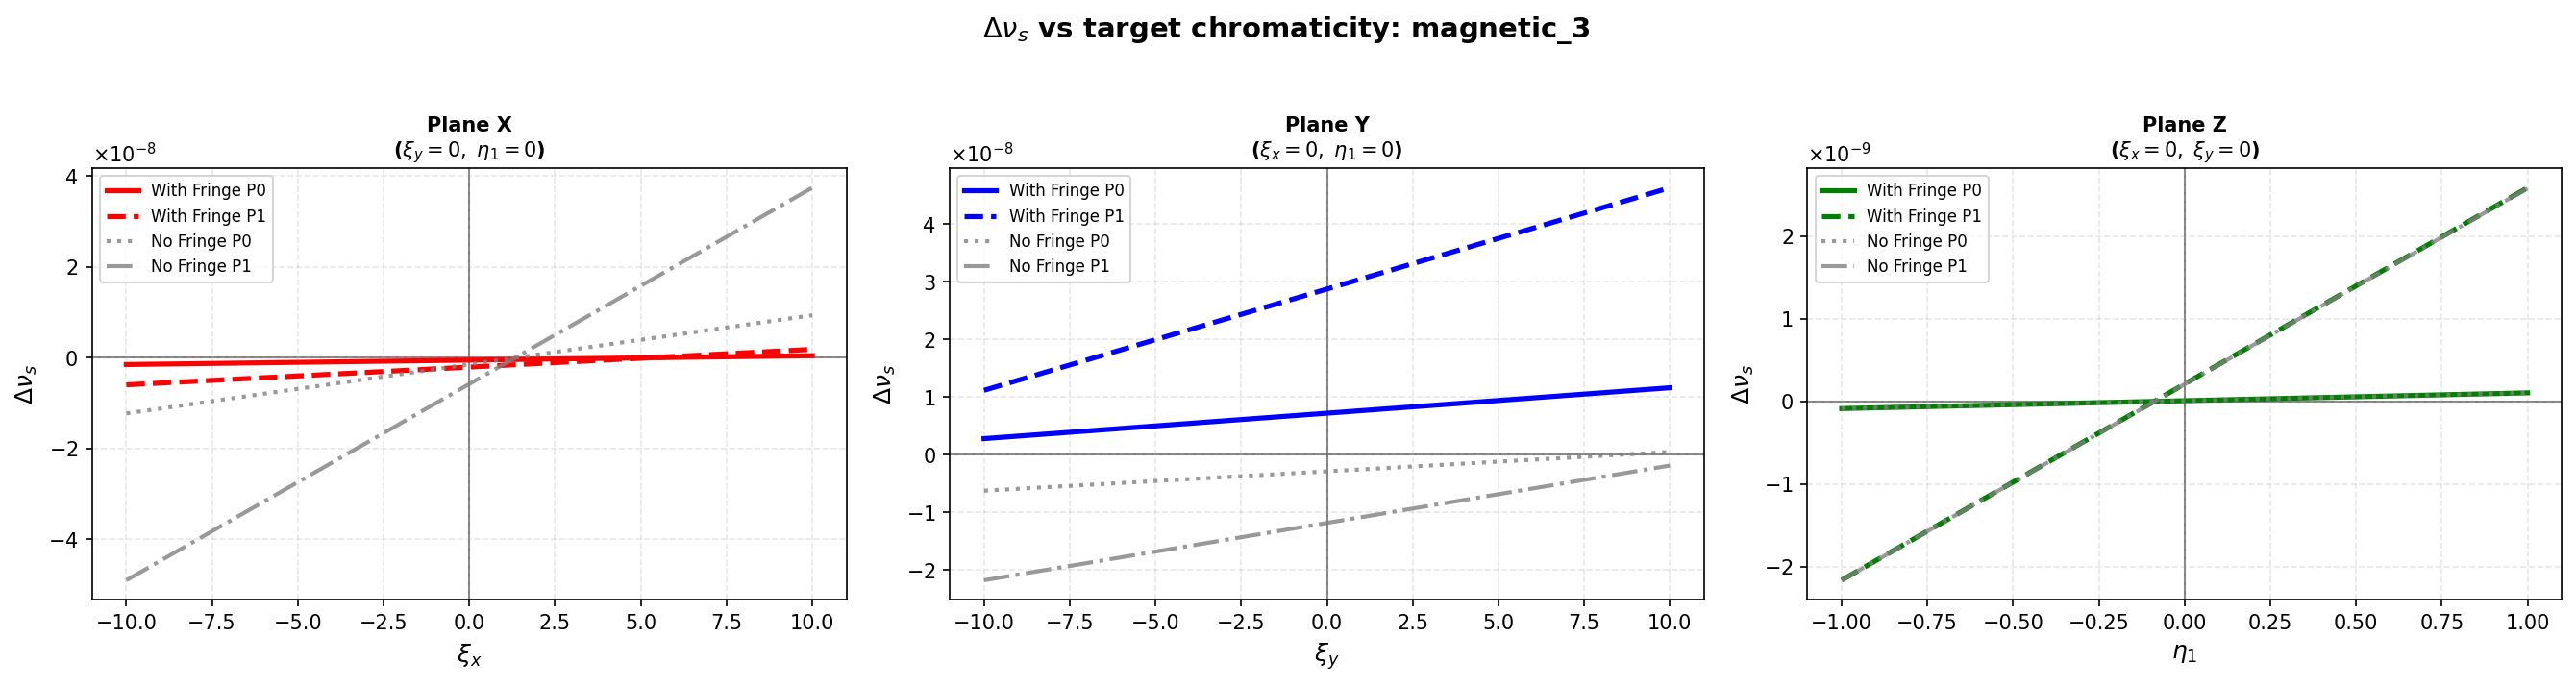

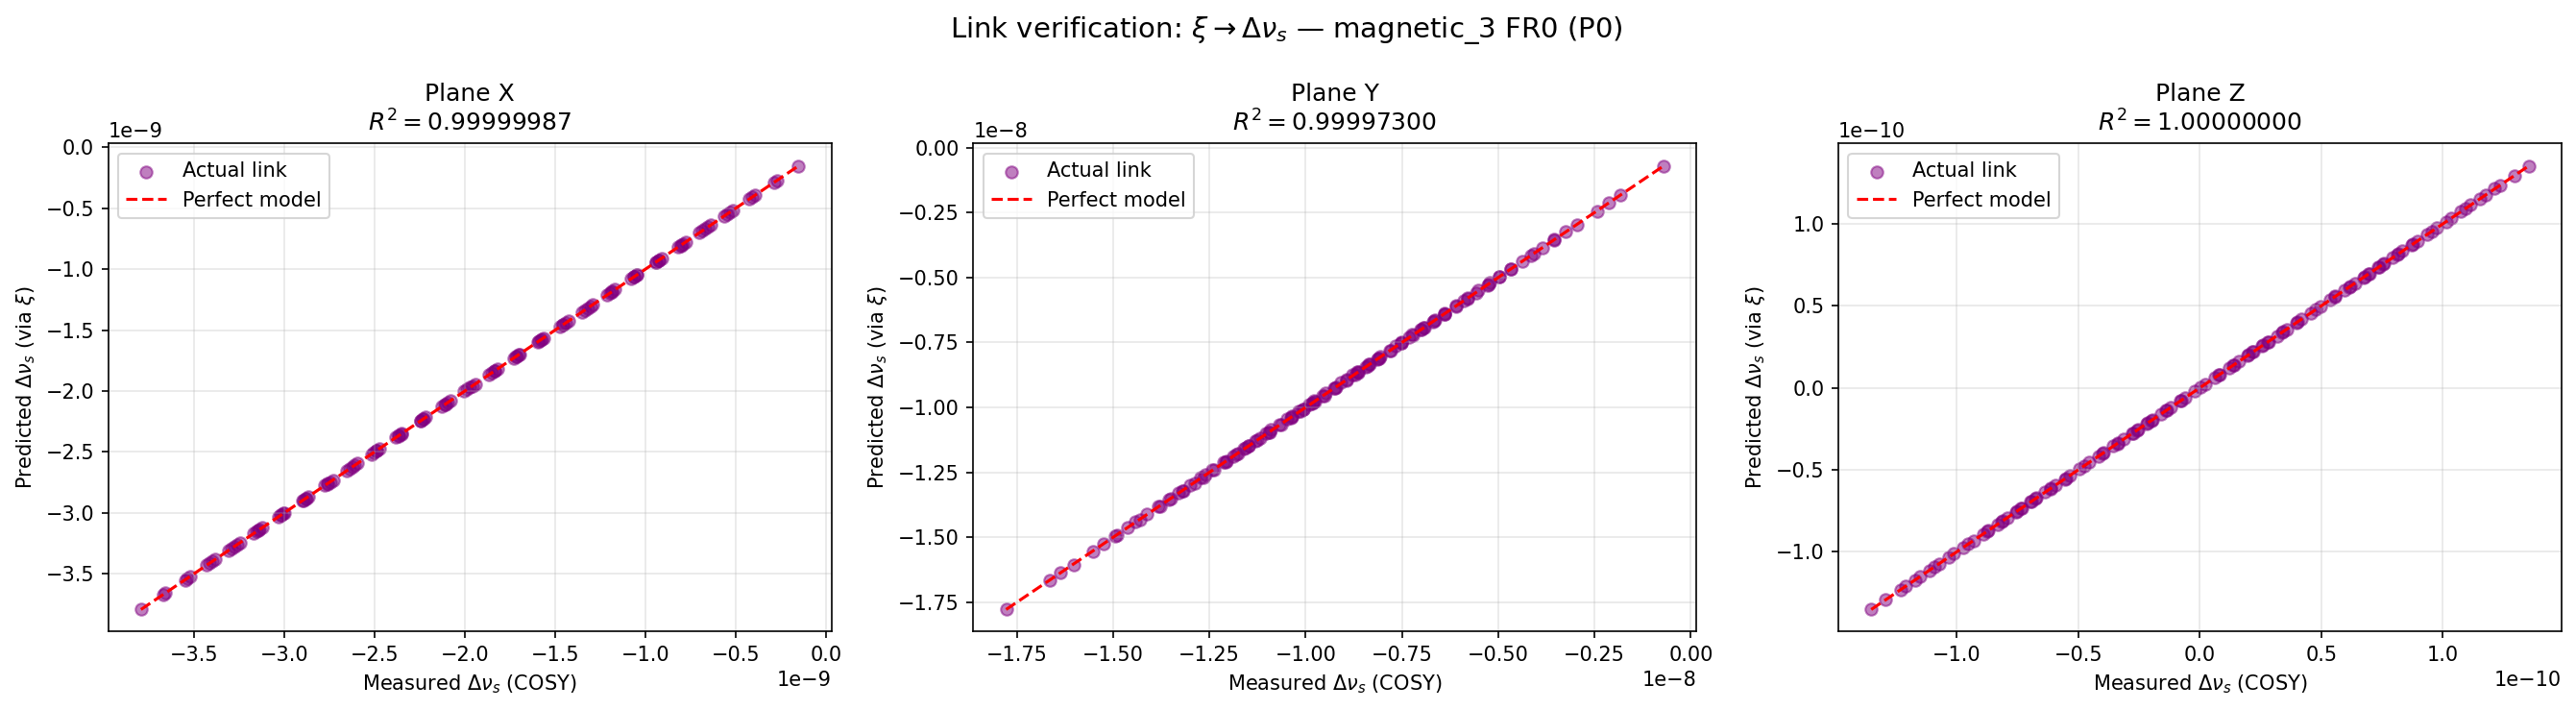

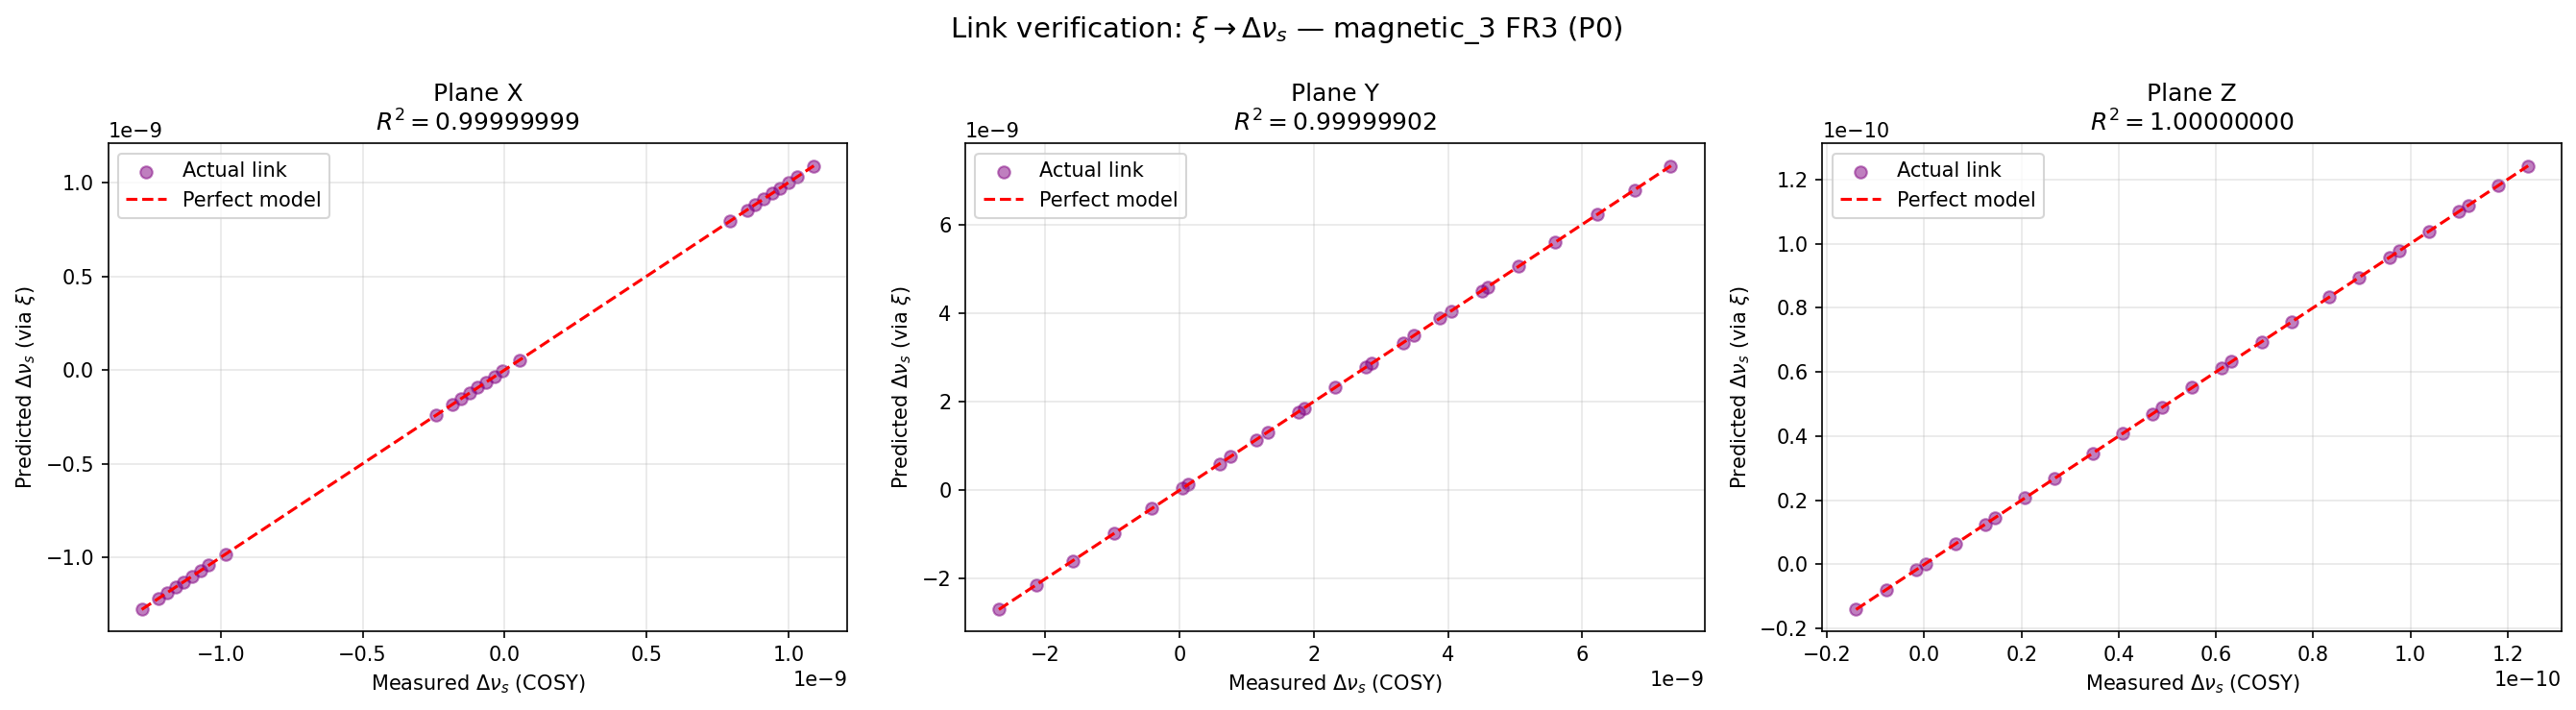

OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_4\plots\magnetic_4_dnu_s_vs_chrom.png


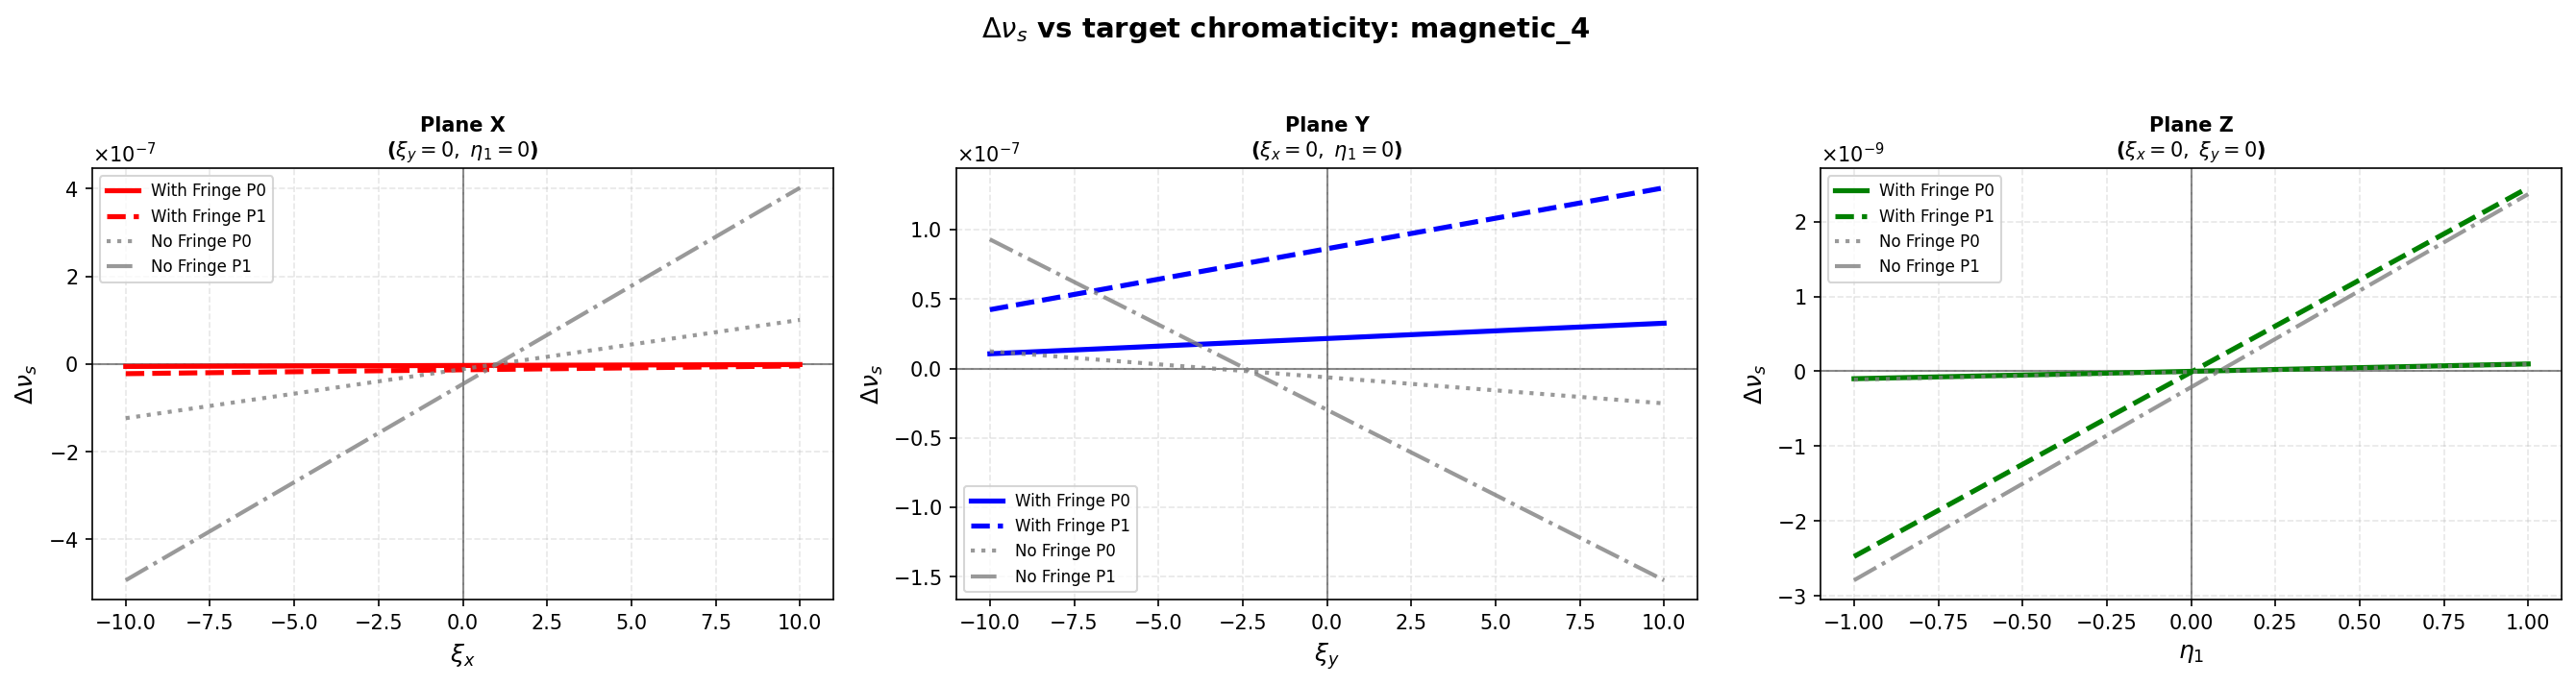

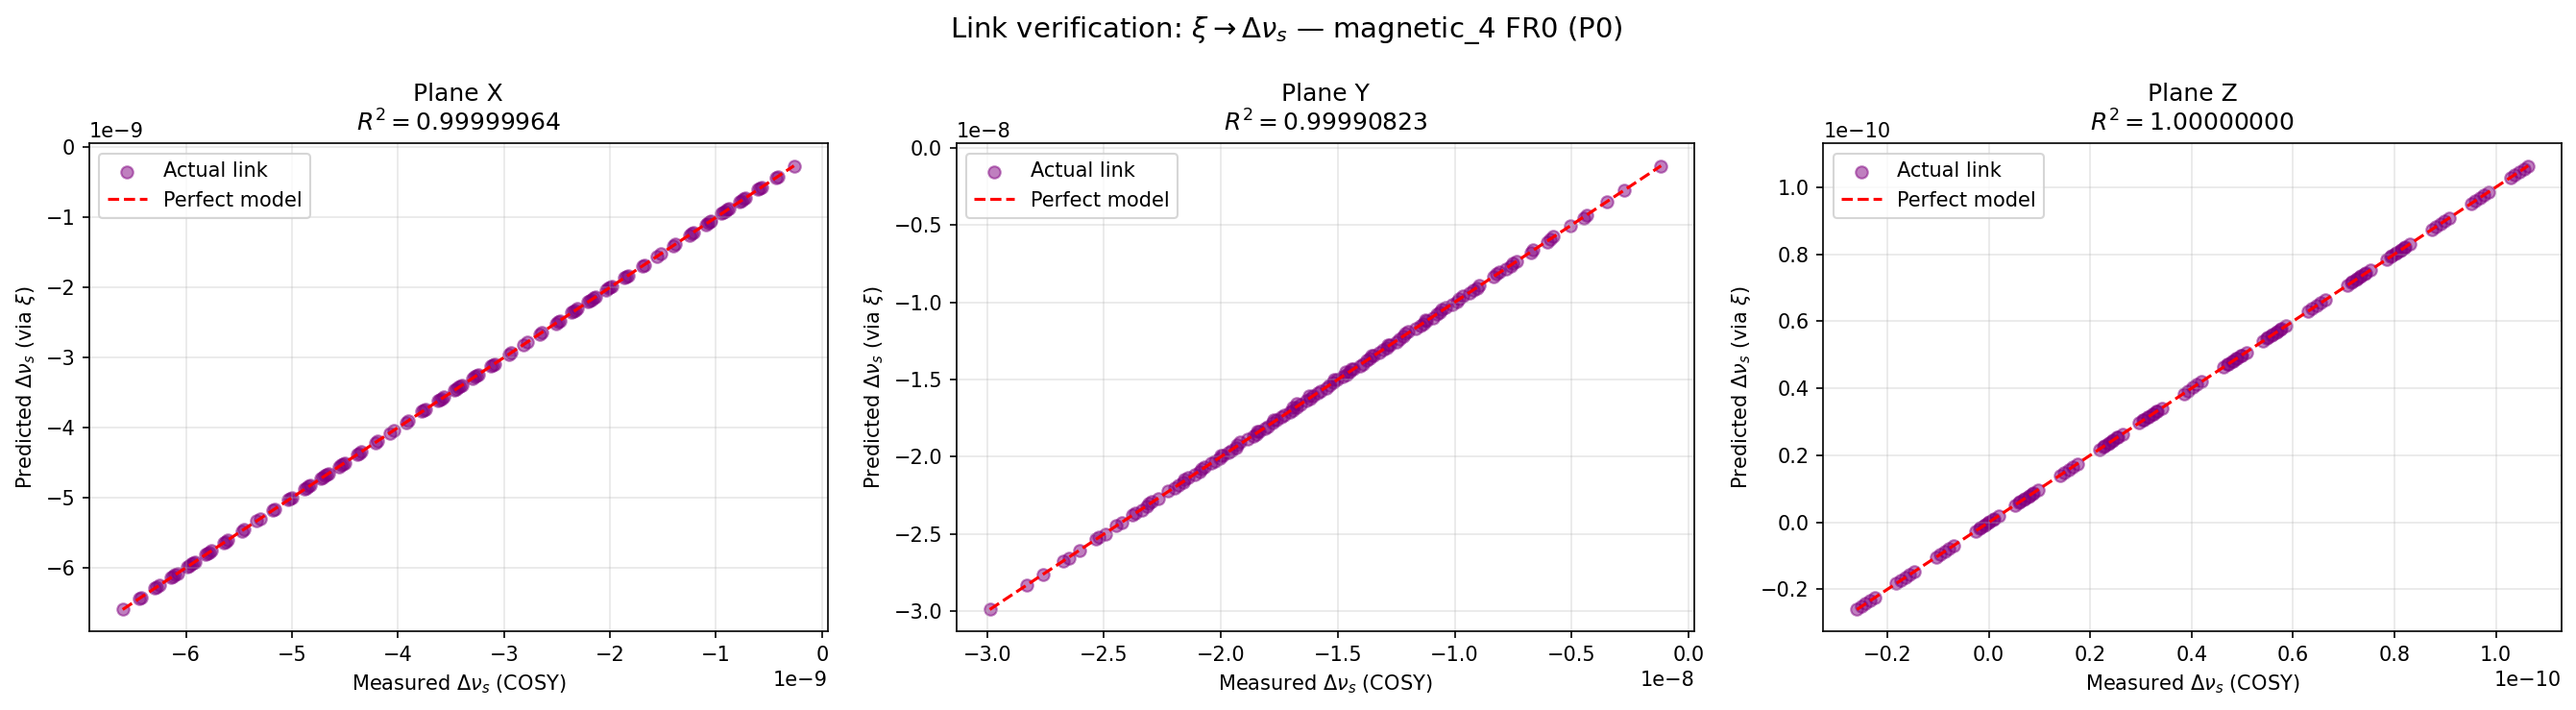

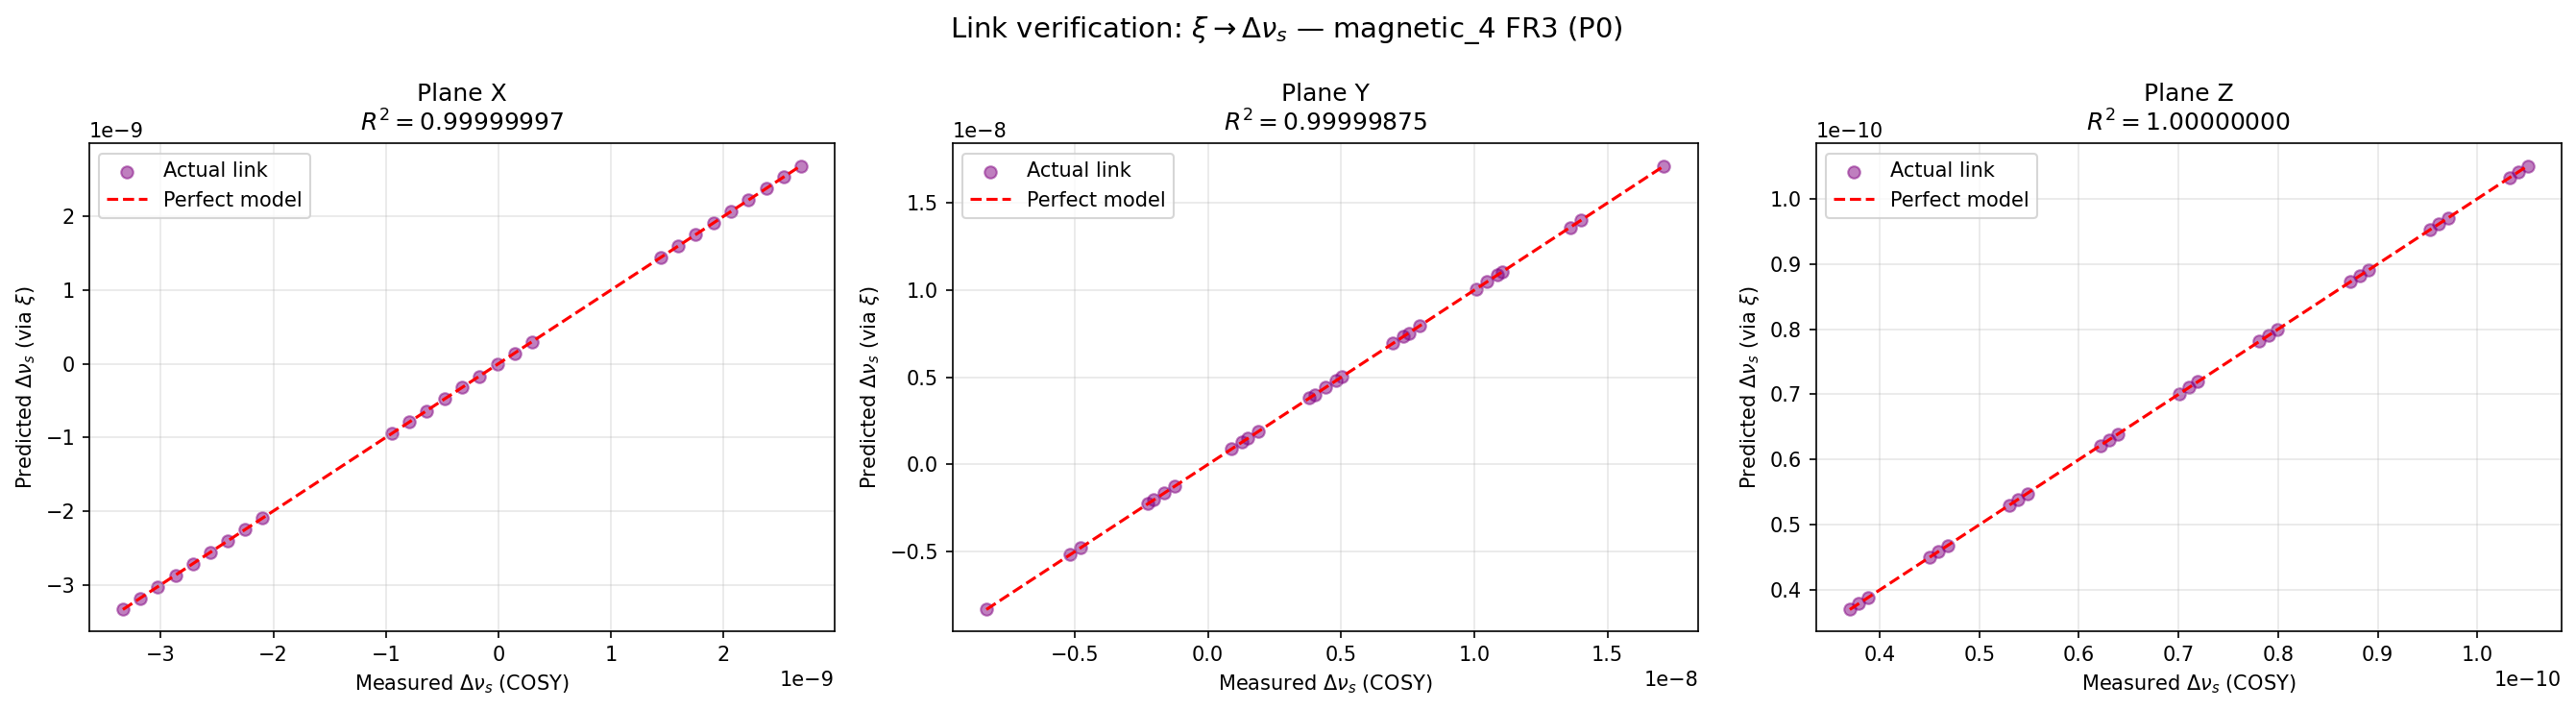

OK: C:\GIT_REPOS\SCT\COSY\src\dat\magnetic_5\plots\magnetic_5_dnu_s_vs_chrom.png


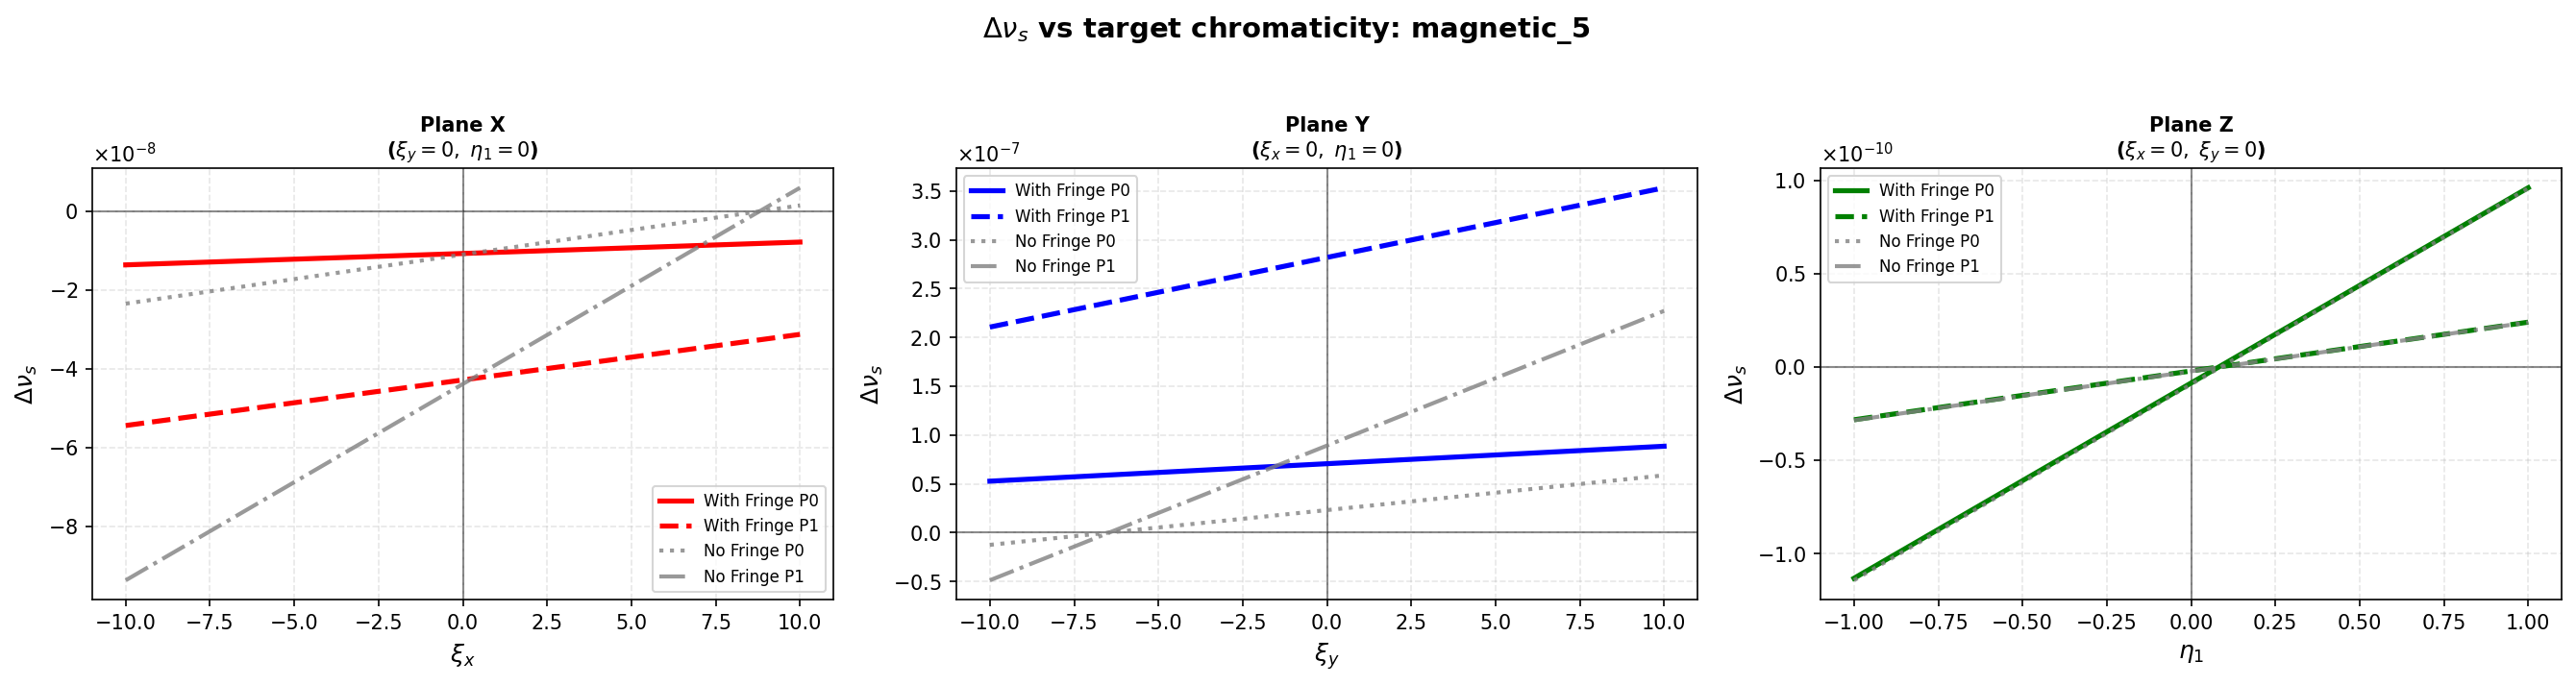

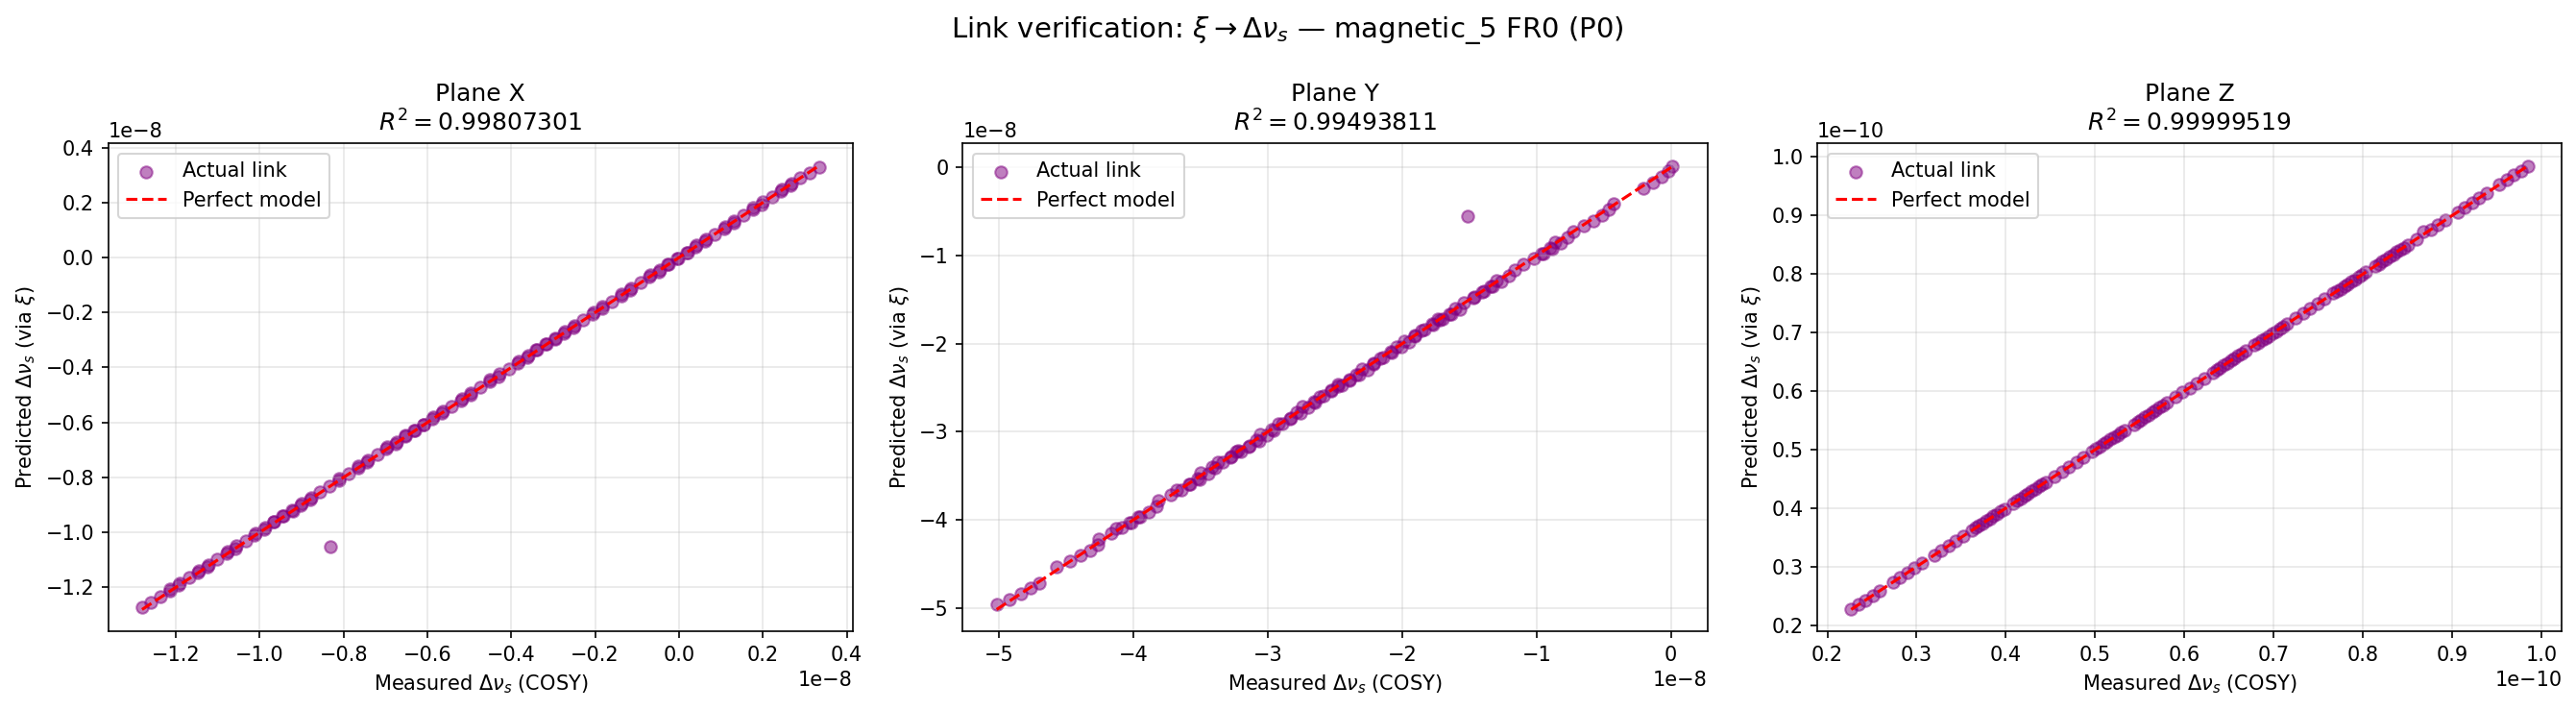

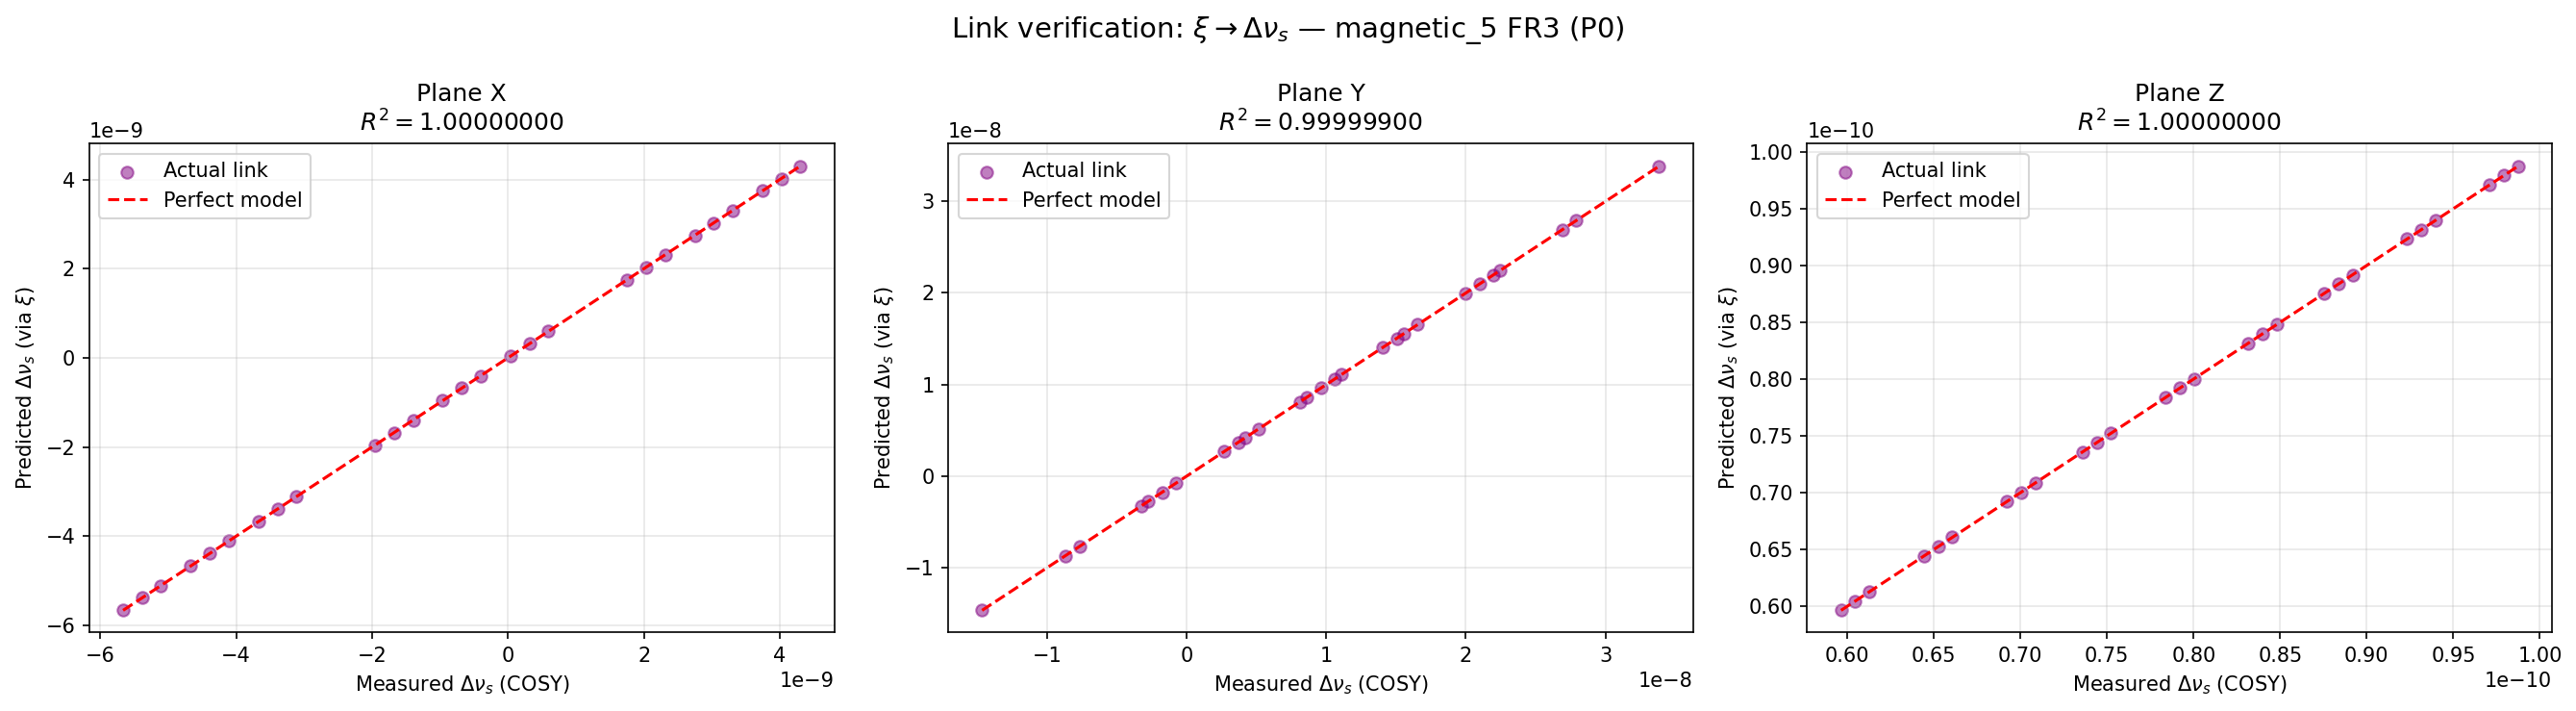

In [6]:
from IPython.display import Image, display

for lat in lattices:
    plot_lattice(lat, DEFAULT_ROOT, show=False)
    plots_dir = DEFAULT_ROOT / lat / "plots"
    for name in [
        f"{lat}_dnu_s_vs_chrom.png",
        f"{lat}_verify_spin_link_FR0_P0.png",
        f"{lat}_verify_spin_link_FR3_P0.png",
    ]:
        p = plots_dir / name
        if p.is_file():
            display(Image(filename=str(p)))